# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

To convert model predictions into trusted human workflows, content is mapped into four distinct action archetypes based on traffic volume, position, and predicted decay risk:

PRIORITY_EDITORIAL_REFRESH (Reason: STALE_HIGH_VOLUME): High-volume pieces with long periods since last update showing decay signals. Highest ROI for manual rewriting.

METADATA_OPTIMIZATION (Reason: LOW_CTR_HIGH_IMP): High impression counts but poor CTR. Requires title tag and meta description testing rather than body copy edits.

CONTENT_RESTRUCTURE (Reason: POSITION_SLIP): Average position dropping out of top positions. Requires structural header updates and intent alignment.

MONITOR_NO_ACTION (Reason: STABLE_PERFORMANCE): Content performing stably or newly published. No human action required.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended Use: This playbook serves as a decision-support queue for SEO strategists and editorial leads. It prioritizes weekly content maintenance budgets based on measured impact rather than guesswork.

Operational Limits: The model identifies directional decay signals, not root causes. It cannot anticipate unannounced search engine core algorithm updates or sudden macroeconomic shifts in user intent. Furthermore, predictions are limited to existing, indexed URLs and do not apply to brand-new content.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human Review Checklist (Mandatory before acting):

    Search Intent Verification: Manually review the current top-ranking SERP results to ensure user intent hasn't fundamentally shifted since the article was written.

    Cannibalization Check: Verify that another page on the same domain isn't already ranking for the target keywords.

    Brand Audit: Ensure that any updated statistics, dates, or claims maintain brand compliance.

The No-Go List (NEVER Automate):

    Automated Rewriting: Never deploy LLM-generated rewrites directly to live URLs without human editing.

    Auto-Deletion: Never programmatically delete pages or execute 301 redirects based solely on low model scores.

    Core Compliance Pages: Terms of service, privacy policies, and core product landing pages are strictly excluded from automated decay triggers.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Model Drift: Retrain the model if overall prediction accuracy on the baseline data drops below 65% during routine monthly checks.

Traffic Anomalies: Re-evaluate all reason codes if overall domain impression volume swings by more than 25% week-over-week, which typically indicates a global search algorithm update rather than standard decay.

Scheduled Recalibration: A full pipeline retrain is scheduled every 90 days to capture shifting baseline behaviors.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

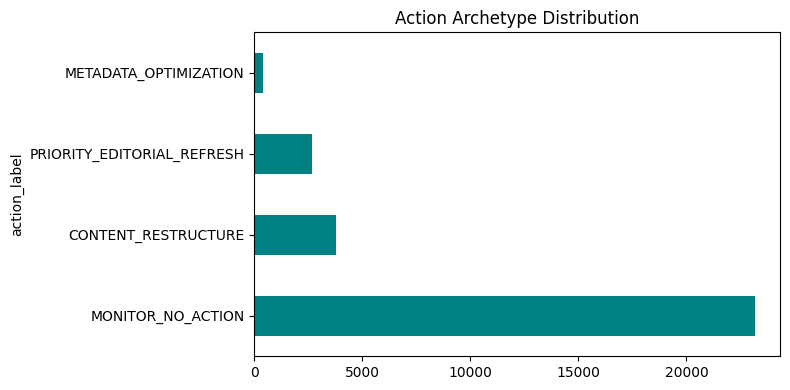

In [1]:
import pandas as pd
import os
import json
import matplotlib.pyplot as plt

os.makedirs("../work/outputs", exist_ok=True)
os.makedirs("../work/figures", exist_ok=True)

df = pd.read_csv("df_ranked.csv")

df['priority_score'] = (df['impressions_90d'] * df['baseline_score']) / (df['avg_position'] + 1)

def assign_archetype(row):
    if row['baseline_score'] >= 70 and row['impressions_90d'] > 5000:
        return 'STALE_HIGH_VOLUME', 'PRIORITY_EDITORIAL_REFRESH'
    elif row['ctr'] < 0.02 and row['impressions_90d'] > 2000:
        return 'LOW_CTR_HIGH_IMP', 'METADATA_OPTIMIZATION'
    elif row['avg_position'] > 10 and row['baseline_score'] >= 50:
        return 'POSITION_SLIP', 'CONTENT_RESTRUCTURE'
    else:
        return 'STABLE_PERFORMANCE', 'MONITOR_NO_ACTION'

df[['reason_code', 'action_label']] = df.apply(assign_archetype, axis=1, result_type='expand')
ranked_queue = df.sort_values(by='priority_score', ascending=False).reset_index(drop=True)

queue_cols = ['content_id', 'client_id', 'priority_score', 'reason_code', 'action_label', 'impressions_90d', 'avg_position']
ranked_queue[queue_cols].to_csv("../work/outputs/ranked_action_queue.csv", index=False)

metrics = {
    "total_pages": int(len(ranked_queue)),
    "action_breakdown": ranked_queue['action_label'].value_counts().to_dict()
}
with open("../work/outputs/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

plt.figure(figsize=(8, 4))
ranked_queue['action_label'].value_counts().plot(kind='barh', color='teal')
plt.title("Action Archetype Distribution")
plt.tight_layout()
plt.savefig("../work/figures/action_distribution.png", dpi=300)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.